In [1]:
import trimesh
import numpy as np
import torch
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(".."))

from src.core import *
import src.viz as viz
import src.io as io

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device ->", device)

cell_cfg = CellConfig(hidden_channels=8, visible_channels=1, alive_threshold=0.05)
perc_cfg = PerceptionConfig(kernel_radius=1, channel_groups=3)
upd_cfg = UpdateConfig(hidden_dim=64, stochastic_update=False, fire_rate=0.5)
grid_cfg = GridConfig(size=(32, 32, 32))

model = Grid3D(cell_cfg, perc_cfg, upd_cfg, grid_cfg).to(device)

device -> cuda


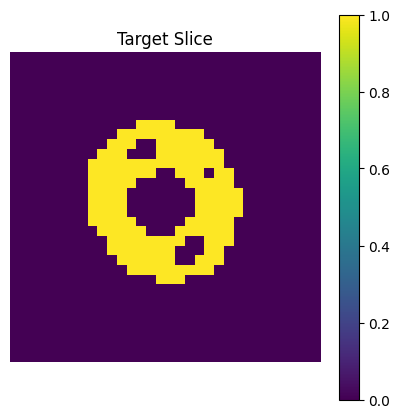

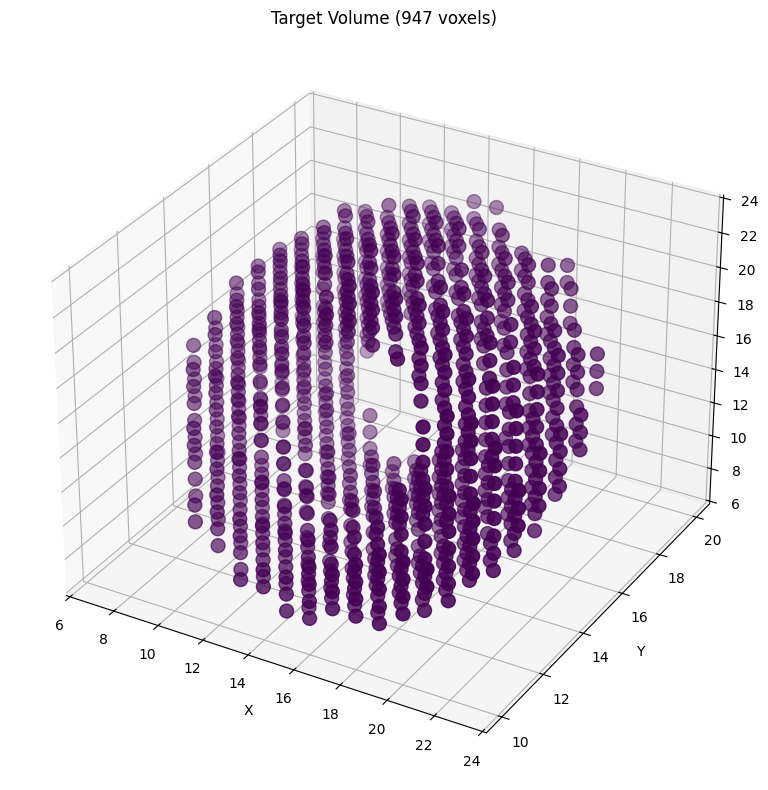

947

In [3]:
filepath = os.path.abspath("../assets/donut/model.obj")
target = io.obj_to_tensor(filepath=filepath, grid_size=(32, 32, 32), mode="alpha", device=device)

viz.show_slice_mpl(target, title="Target Slice", axis=1, idx=15)
viz.show_volume_mpl(target, title="Target Volume", point_size=100)

In [4]:
print("stability run:")
state = model.seed_center(batch_size=1, device=device)
state += 1e-3 * torch.randn_like(state)
with torch.no_grad():
    for i in range(8):
        state = model(state, steps=1)
        print(f"step {i:02d} mean={state.mean().item():+.6f} std={state.std().item():.6f}")

stability run:
step 00 mean=+0.000003 std=0.001842
step 01 mean=+0.000003 std=0.001842
step 02 mean=+0.000003 std=0.001842
step 03 mean=+0.000003 std=0.001842
step 04 mean=+0.000003 std=0.001842
step 05 mean=+0.000003 std=0.001842
step 06 mean=+0.000003 std=0.001842
step 07 mean=+0.000003 std=0.001842



starting multi-step training
Iter 00001, Loss=0.231712, Mean Alpha=0.0003


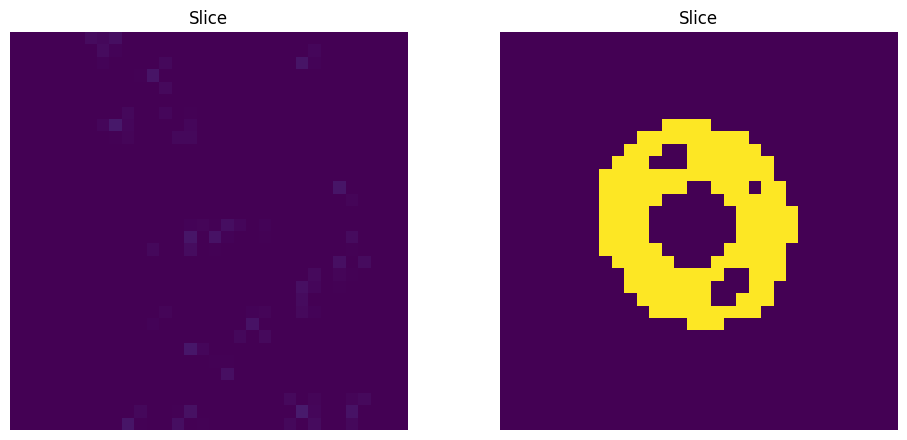

Iter 00200, Loss=0.229604, Mean Alpha=0.0006


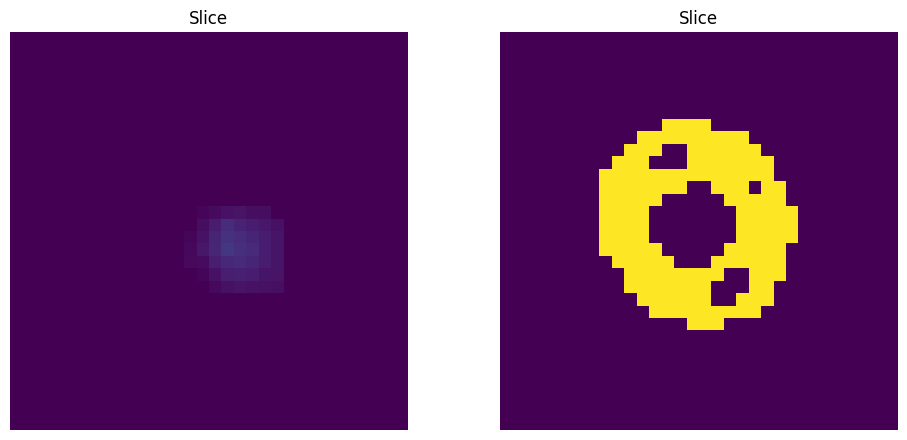

Iter 00400, Loss=0.204744, Mean Alpha=0.0205


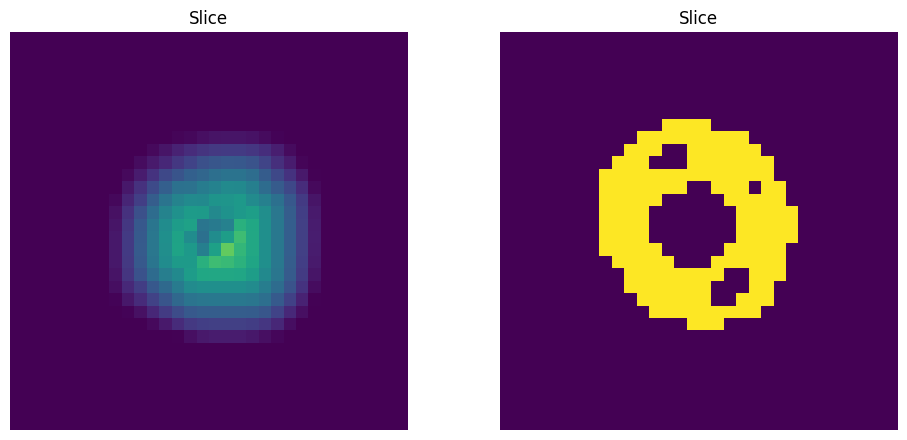

Iter 00600, Loss=0.195499, Mean Alpha=0.0192


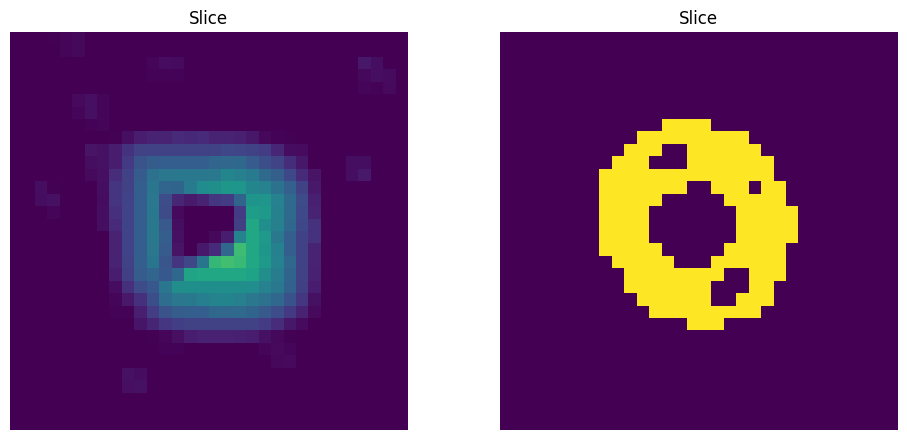

Iter 00800, Loss=0.191590, Mean Alpha=0.0168


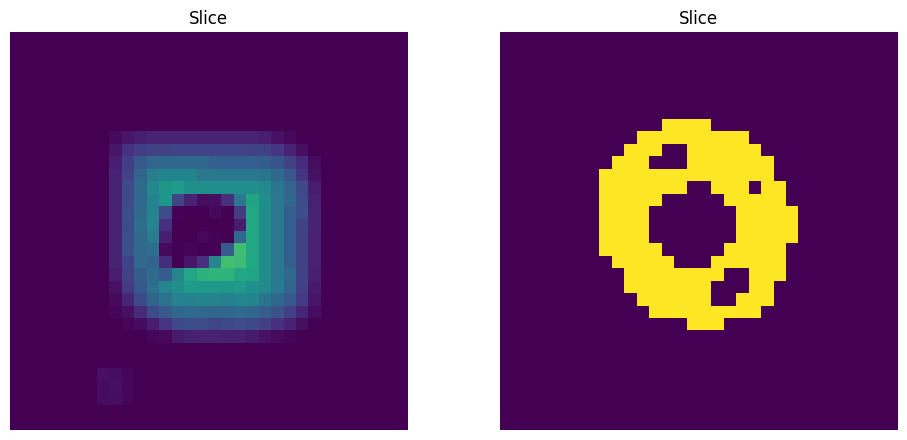

Iter 01000, Loss=0.192385, Mean Alpha=0.0177


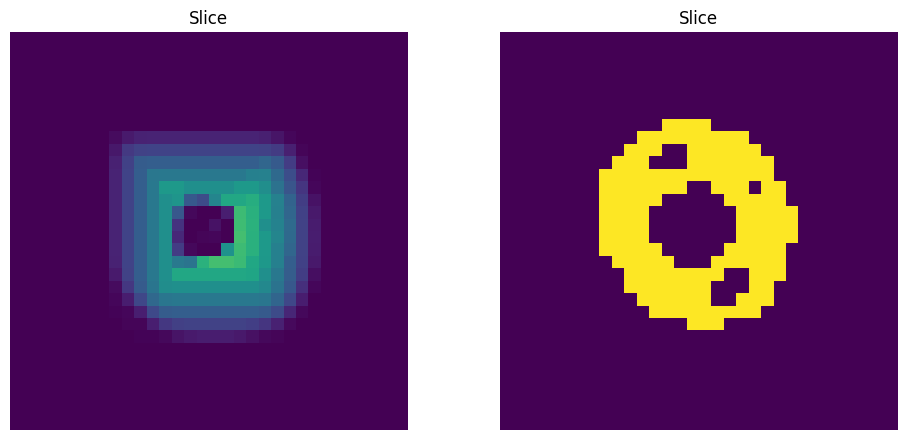

Iter 01200, Loss=0.193517, Mean Alpha=0.0152


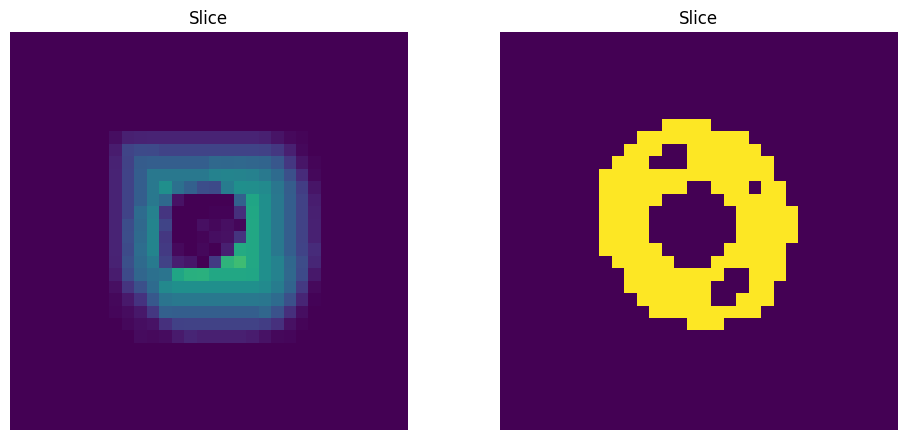

Iter 01400, Loss=0.188894, Mean Alpha=0.0153


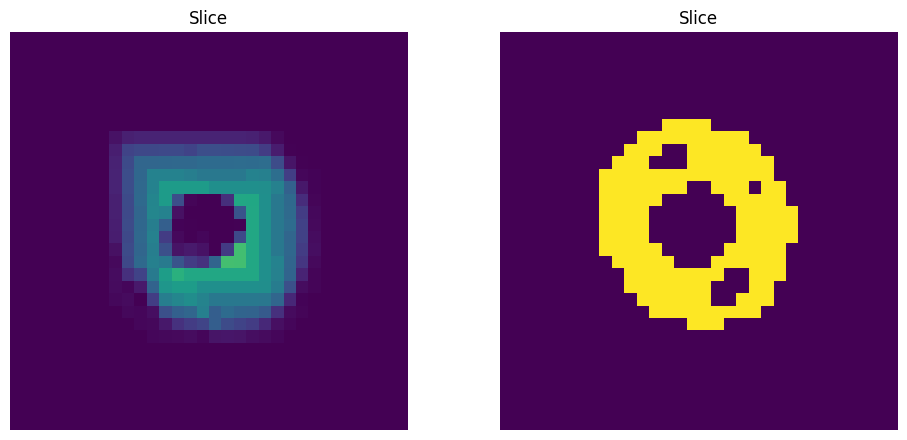

Iter 01600, Loss=0.191067, Mean Alpha=0.0172


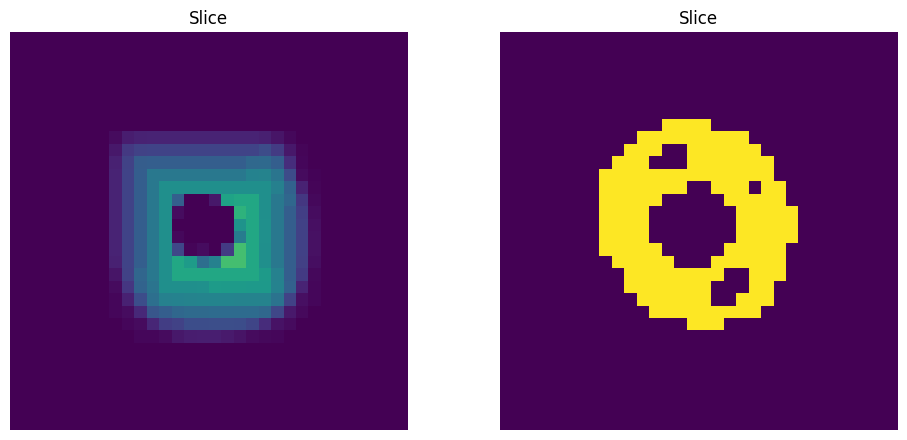

Iter 01800, Loss=0.189243, Mean Alpha=0.0160


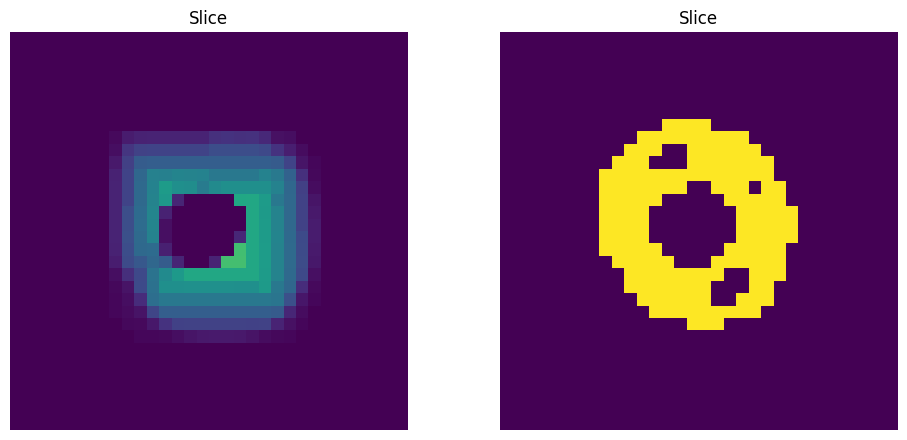

Iter 02000, Loss=0.190962, Mean Alpha=0.0140


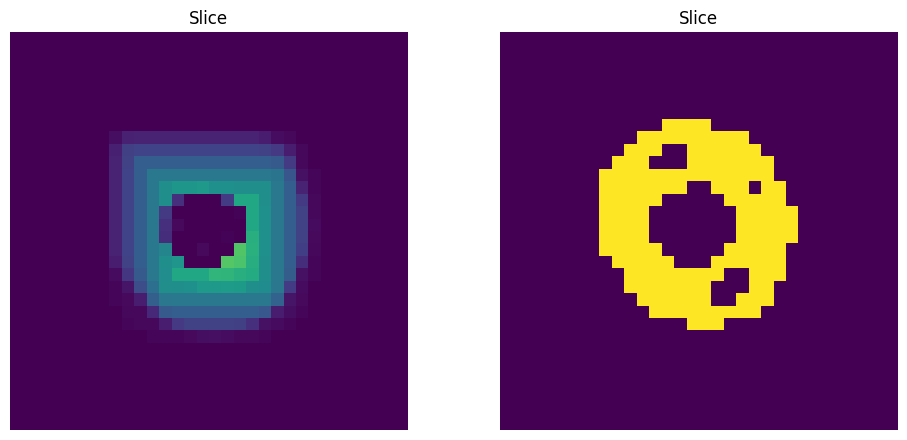

training took 69.11581063270569 s


In [5]:
print("\nstarting multi-step training")
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
losses = []
iters = 2000
n_steps = 8
log_interval = 200

start = time.time()
for it in range(1, iters+1):
    state = model.seed_center(batch_size=1, device=device)
    state += 0.02 * torch.randn_like(state)
    optim.zero_grad()
    loss = 0.0
    for step in range(n_steps):
        state = model(state, steps=1)
        alpha = state[:, -1:, ...]
        loss += F.mse_loss(alpha, target)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optim.step()
    losses.append(loss.item())
    
    if it % log_interval == 0 or it==1:
        print(f"Iter {it:05d}, Loss={loss.item():.6f}, Mean Alpha={alpha.mean().item():.4f}")
        viz.show_slice_comparison_mpl(state, target, axis=1, idx=15)
    if loss.item() < 0.095:
        print("Best result")
        print(f"Iter {it:05d}, Loss={loss.item():.6f}, Mean Alpha={alpha.mean().item():.4f}")
        viz.show_slice_comparison_mpl(state, target, axis=1, idx=15)
        break

print("training took", time.time() - start, "s")

final alive voxels: 986


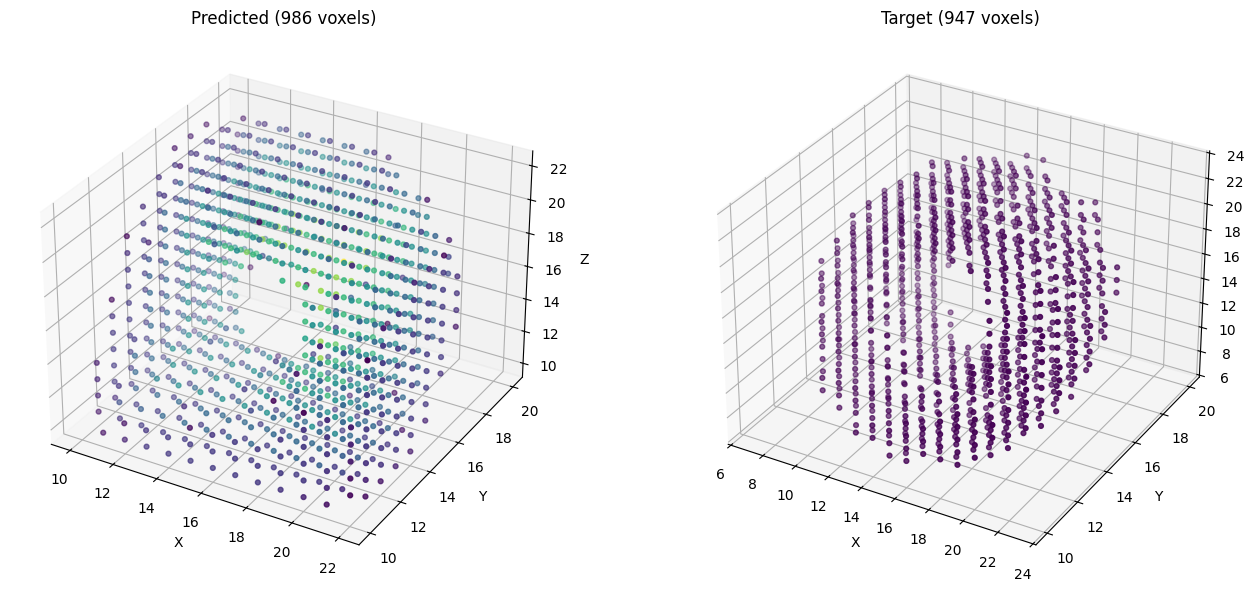

(986, 947)

In [6]:
with torch.no_grad():
    state = model.seed_center(batch_size=1, device=device)
    state += 1e-3 * torch.randn_like(state)
    state = model(state, steps=8)
    alpha = state[:, -1:, ...].cpu().numpy().squeeze()

thresh = 0.2
xs, ys, zs = np.nonzero(alpha > thresh)
print("final alive voxels:", len(xs))
viz.show_volume_comparison_mpl(state, target, point_size=12)

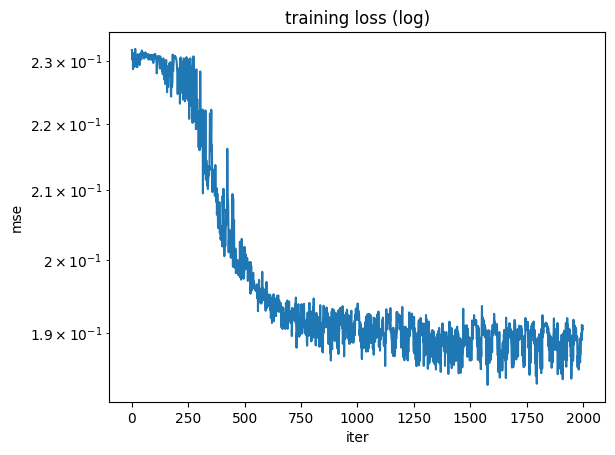

In [7]:
plt.figure()
plt.plot(losses)
plt.yscale("log")
plt.title("training loss (log)")
plt.xlabel("iter")
plt.ylabel("mse")
plt.show()